## Visualize Annual Corn Production by State

This notebook creates time series plots and other visualizations of annual corn production using USDA NASS data from 1866-2025.

Click the badge below to open in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chuckgrigsby0/agec-370/blob/main/notebooks/13_plot_annual_corn_production_bushels.ipynb)

## Data Loading

Import necessary libraries and load the corn production dataset.

In [33]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from GitHub repository
base_url = "https://raw.githubusercontent.com/chuckgrigsby0/agec-370/main/data/"
corn_prod = pd.read_csv(base_url + 'corn_production_bushels.csv')

## Data Exploration

Examine the structure and content of the corn production data.

In [34]:
# Display column names to understand data structure
print(corn_prod.columns.tolist())

['year', 'state_name', 'reference_period_desc', 'freq_desc', 'unit_desc', 'sector_desc', 'class_desc', 'commodity_desc', 'short_desc', 'group_desc', 'statisticcat_desc', 'Value']


In [35]:
# Preview first few rows
print(corn_prod.head())

   year state_name reference_period_desc freq_desc unit_desc sector_desc  \
0  2025   US TOTAL                  YEAR    ANNUAL        BU       CROPS   
1  2024   US TOTAL                  YEAR    ANNUAL        BU       CROPS   
2  2023   US TOTAL                  YEAR    ANNUAL        BU       CROPS   
3  2022   US TOTAL                  YEAR    ANNUAL        BU       CROPS   
4  2021   US TOTAL                  YEAR    ANNUAL        BU       CROPS   

    class_desc commodity_desc                                short_desc  \
0  ALL CLASSES           CORN  CORN, GRAIN - PRODUCTION, MEASURED IN BU   
1  ALL CLASSES           CORN  CORN, GRAIN - PRODUCTION, MEASURED IN BU   
2  ALL CLASSES           CORN  CORN, GRAIN - PRODUCTION, MEASURED IN BU   
3  ALL CLASSES           CORN  CORN, GRAIN - PRODUCTION, MEASURED IN BU   
4  ALL CLASSES           CORN  CORN, GRAIN - PRODUCTION, MEASURED IN BU   

    group_desc statisticcat_desc           Value  
0  FIELD CROPS        PRODUCTION  17,020,

### Clean `Value` Column

In [36]:
value_clean = corn_prod['Value'].fillna('').astype(str)

# Remove any row containing (D) or (Z) anywhere
mask = value_clean.str.contains(r'\([DZ]\)', regex=True)
corn_prod = corn_prod[~mask].copy()

# Remove ',' from `Value` column
corn_prod['Value'] = (
    corn_prod['Value']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
# Convert to numeric
corn_prod['Value'] = pd.to_numeric(corn_prod['Value'], errors='coerce')

# Check for NAs
print(corn_prod['Value'].isna().sum())

# Optional: Drop NAs if needed
# corn_prod.dropna(subset=['Value'], inplace=True) 

0


In [37]:
np.sort(corn_prod.year.unique())

array([1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876,
       1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887,
       1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898,
       1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909,
       1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920,
       1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931,
       1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942,
       1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953,
       1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964,
       1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 20

In [38]:
# Generate summary statistics
np.round(corn_prod.describe(), decimals=2)

,year,Value
count,160.00,1.600000e+02
mean,1945.50,5.012286e+09
std,46.33,4.142784e+09
min,1866.00,7.308140e+08
25%,1905.75,2.245450e+09
50%,1945.50,2.862876e+09
75%,1985.25,7.489062e+09
max,2025.00,1.702055e+10


In [39]:
# Verify data frequency (should be annual)
print(corn_prod['freq_desc'].unique())

['ANNUAL']


## Data Preparation

Convert acres to millions for better readability in visualizations.

In [40]:
# Convert acres to millions for easier interpretation in plots
corn_prod = corn_prod.assign( 
    corn_prod_bu=lambda x: x['Value'] / 1_000_000_000
)

## Visualizations

Set visualization style and create plots.

In [41]:
# Set the style for seaborn plots
# 'whitegrid' provides a clean background with subtle gridlines
sns.set_style('whitegrid')

### Single-State Line Plot

Visualize corn production (millions of bushels) over time. 

Documentation: [Seaborn Line Plot](https://seaborn.pydata.org/generated/seaborn.lineplot.html)

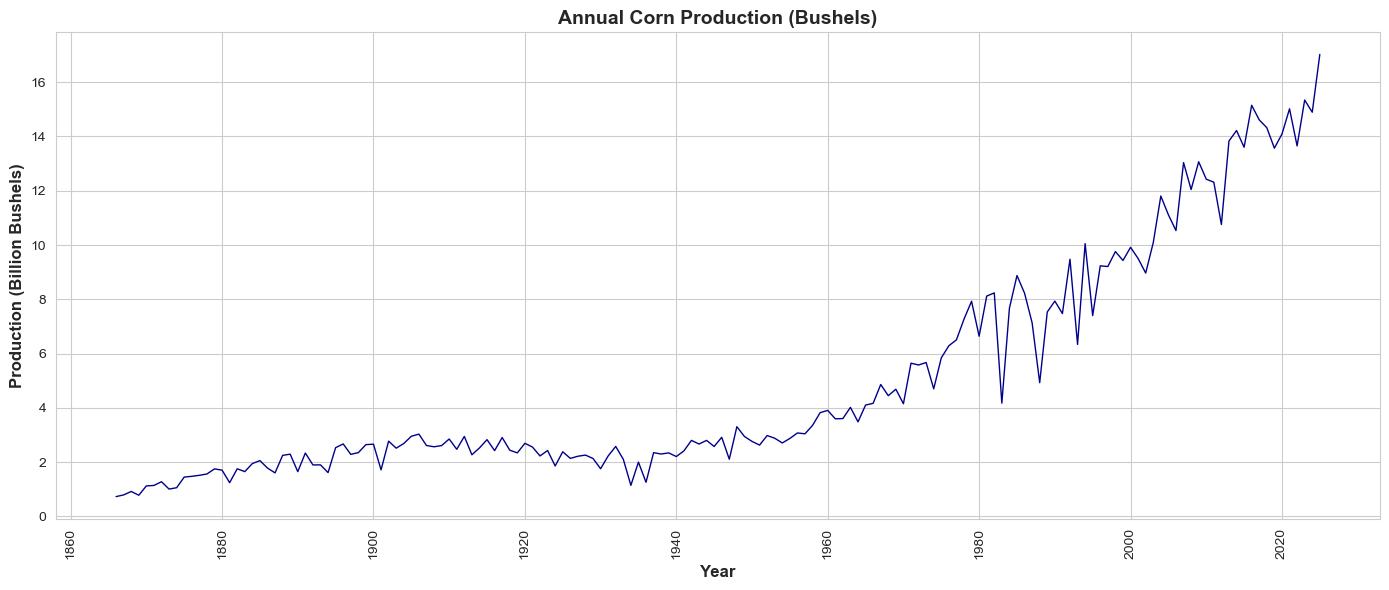

In [42]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=corn_prod,
    x='year',
    y='corn_prod_bu',
    linewidth=1.0,
    color='darkblue'
)

plt.title("Annual Corn Production (Bushels)", fontsize=14, weight='bold')
plt.xlabel("Year", fontsize=12, weight='bold')
plt.ylabel("Production (Billion Bushels)", fontsize=12, weight='bold')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

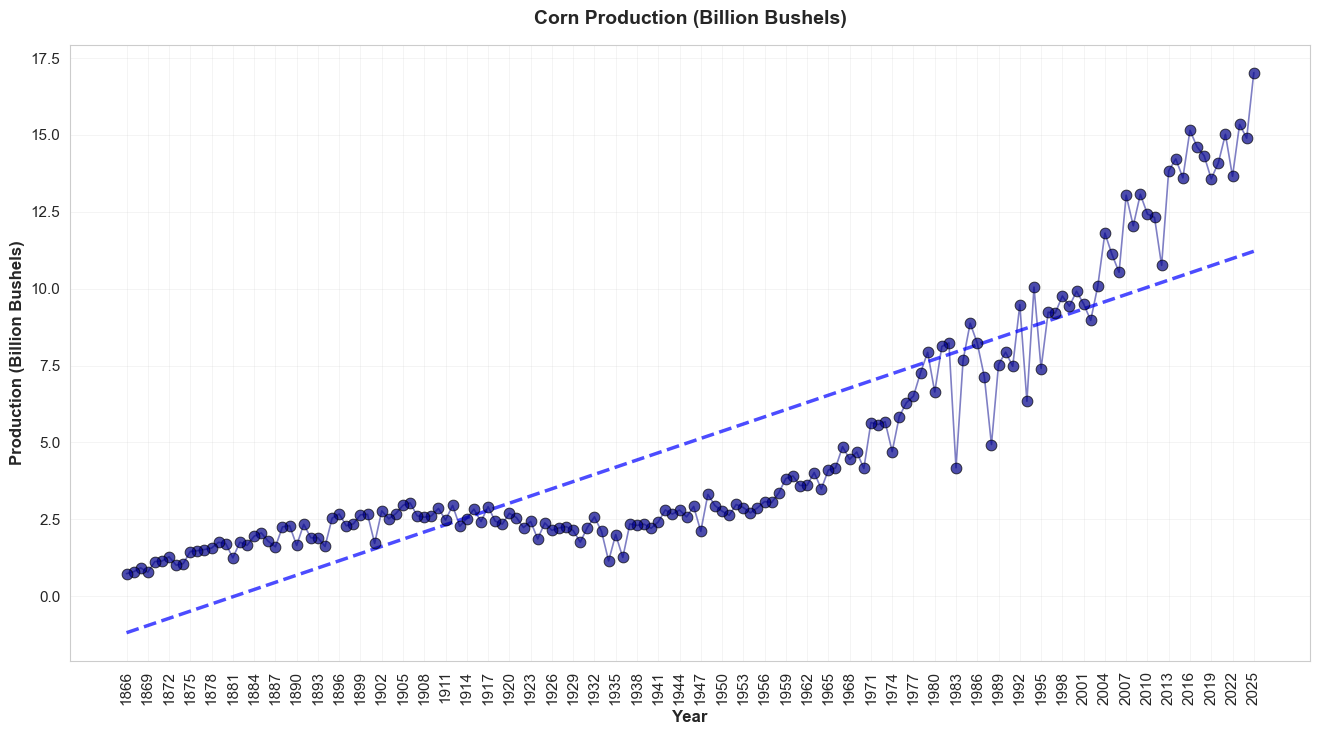

In [45]:
# Create corn production figure with regression line and connected points
# figsize=(16, 8) creates a wide figure to accommodate two plots
# ncols=2 creates two columns for side-by-side comparison
from matplotlib import axes


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))

# ============================================================
# Plot production with regression line
# ============================================================

# regplot creates both scatterplot and fitted regression line
# ci=None turns off the confidence interval shading
sns.regplot(
    data=corn_prod,  # Use the merged dataframe
    x='year',  # Year on x-axis
    y='corn_prod_bu',  # Nominal price on y-axis
    scatter_kws={
        'alpha': 0.7,  # Transparency: 0.7 makes points visible but not overpowering
        's': 60,  # Size of scatter points (60 is moderately sized)
        'color': 'darkblue',  # Color for nominal price points
        'edgecolors': 'black',  # Black border around points for definition
        'linewidths': 0.7,  # Border width
        'zorder': 3  # zorder=3 ensures points appear above lines
    },
    line_kws={
        'color': 'blue',  # Blue regression line for nominal prices
        'linewidth': 2.5,  # Thick line for visibility
        'linestyle': '--',  # Dashed line to distinguish from connected line
        'alpha': 0.7,  # Slight transparency
        'zorder': 2  # zorder=2 places regression line above grid but below points
    },
    ci=None,  # Turn off confidence interval shading
    ax=ax  # Plot on first (left) subplot
)

# Add connected line plot to show year-to-year changes
# This connects consecutive years with a line to show temporal progression
ax.plot(
    corn_prod['year'],  # X values: years
    corn_prod['corn_prod_bu'],  # Y values: corn production in bushels
    color='darkblue',  # Match scatter point color
    linewidth=1.2,  # Thin line so it doesn't overpower scatter and regression
    alpha=0.5,  # Semi-transparent to show as background connection
    zorder=1  # zorder=1 places connected line behind everything else
)

# Set title for production plot
# fontsize=14 makes subtitle prominent, weight='bold' emphasizes it
ax.set_title(
    'Corn Production (Billion Bushels)',
    fontsize=14,
    weight='bold',
    pad=15  # Add 15 points of padding above title
)

# Set x-axis label for production plot
ax.set_xlabel('Year', fontsize=12, weight='bold')

# Set y-axis label for production plot
ax.set_ylabel('Production (Billion Bushels)', fontsize=12, weight='bold')

# Set x-axis to display every year in the dataset
# Get all unique years from the data and sort them
all_years = sorted(corn_prod['year'].unique())
# Set x-tick locations to show every year
ax.set_xticks(all_years[::3])
# Set x-tick labels to match the years
ax.set_xticklabels(all_years[::3])


# Increase font size of tick labels and rotate x-axis labels to 90 degrees
# labelsize=11 makes year and price values easier to read
# rotation=90 for x-axis makes vertical year labels that don't overlap
# ha='center' aligns rotated labels centered on tick marks
ax.tick_params(axis='y', labelsize=11)  # Y-axis tick label size
ax.tick_params(axis='x', labelsize=11, rotation=90)  # X-axis: larger labels, 90° rotation

# Add grid for easier reading of values
ax.grid(
    axis='both',  # Add gridlines for both x and y axes
    alpha=0.3,  # Make gridlines subtle (30% opacity)
    linestyle='-',  # Use solid lines
    linewidth=0.5  # Make gridlines thin
)

fig.savefig('output/figures/corn_production_annual.png', dpi=150, bbox_inches='tight')